## Exploratory Data Analysis — Invoice & Supplier Dataset

**Purpose:** Characterise the shape, quality, and behavioural patterns of the synthetic South African invoice dataset to surface actionable insights for the finadmin360 platform.

**WM04 Part:** Part 3 — Exploratory Data Analysis

**WM04 Activity codes:** WA0104 (data profiling), WA0119 (univariate analysis), WA0110 (bivariate/multivariate analysis)

**Inputs:**
- `data/synthetic/sa_invoices.csv` — 2 000 synthetic South African invoices
- `data/synthetic/sa_suppliers.csv` — supplier master data

**Outputs:**
- `reports/eda_invoice_amounts.png`
- `reports/eda_monthly_trend.png`
- `reports/eda_late_by_category.png`
- `reports/eda_correlation.png`
- Key findings documented in Section 6

**Author:** Ntsikelelo Nicholas Jantjie  
**Date:** June 2026

---

### Context

A South African finance administrator currently manages ~2 000 invoices per year across roughly 50 suppliers using manual spreadsheets. Late payments incur penalties, damage supplier relationships, and create cash-flow blind spots. This EDA is the first analytical layer of the finadmin360 platform — it answers the question: *what does the data look like, and where is the pain?*

The dataset covers invoices spanning roughly 12 months, categorised across service types (Legal, IT, Catering, etc.), with fields for payment terms, actual payment date, VAT, and a flag for whether the invoice was paid late.

### Analytical Questions
1. What is the distribution of invoice values, and are there outliers?
2. How has spend and invoice volume trended month on month?
3. Which supplier categories are most prone to late payment?
4. What numeric features correlate most strongly with late payment?
5. What are the five most important findings for the business?

---
## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
BRAND_BLUE   = '#1f77b4'
BRAND_TEAL   = '#17becf'
BRAND_ORANGE = '#ff7f0e'
BRAND_RED    = '#d62728'

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('reports', exist_ok=True)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Environment ready.')

Environment ready.


---
## 1. Data Ingestion & Schema Validation

Before any analysis, we validate that the files exist, parse dates correctly, and confirm the merge key (`supplier_id`) is clean. A silent merge failure — or a type mismatch — would corrupt every downstream insight.

In [2]:
# ── Load raw files ────────────────────────────────────────────────────────────
invoices = pd.read_csv(
    '../data/synthetic/sa_invoices.csv',
    parse_dates=['invoice_date', 'due_date', 'payment_date']
)
suppliers = pd.read_csv('../data/synthetic/sa_suppliers.csv')

print(f'Invoices:  {invoices.shape[0]:,} rows × {invoices.shape[1]} cols')
print(f'Suppliers: {suppliers.shape[0]:,} rows × {suppliers.shape[1]} cols')

Invoices:  2,000 rows × 15 cols
Suppliers: 50 rows × 11 cols


In [3]:
# ── Merge integrity check ─────────────────────────────────────────────────────
# Every invoice must have a matching supplier. We use an indicator to surface
# any orphaned records before they silently become NaN rows downstream.

df = invoices.merge(suppliers, on='supplier_id', how='left', indicator=True)

merge_report = df['_merge'].value_counts()
print('Merge diagnostic:')
print(merge_report)

assert (merge_report.get('right_only', 0) == 0), \
    'Orphaned supplier records — investigate supplier master'
assert (merge_report.get('left_only', 0) == 0), \
    'Invoices with no matching supplier — data quality issue'

df.drop(columns='_merge', inplace=True)
print(f'\nMerged dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')

Merge diagnostic:
_merge
both          2000
left_only        0
right_only       0
Name: count, dtype: int64

Merged dataset: 2,000 rows × 25 cols


In [4]:
# ── Column name disambiguation ────────────────────────────────────────────────
# The merge creates suffix collisions on shared column names:
#   category          → category_x (invoices)  / category_y (suppliers)
#   payment_terms_days → payment_terms_days_x  / payment_terms_days_y
# We keep the invoice-level versions as the analytical primary.

print('Columns after merge:')
print(df.columns.tolist())

Columns after merge:
['invoice_id', 'supplier_id', 'invoice_date', 'due_date', 'payment_date', 'amount_excl_vat', 'vat_amount', 'amount_incl_vat', 'currency', 'category_x', 'payment_terms_days_x', 'days_past_due', 'is_late', 'is_paid', 'invoice_status', 'supplier_name', 'cipc_number', 'vat_number', 'category_y', 'payment_terms_days_y', 'avg_invoice_value_zar', 'late_payment_probability', 'email', 'city', 'created_at']


In [5]:
# ── Dataset snapshot ──────────────────────────────────────────────────────────
print(f'Date range:        {df["invoice_date"].min().date()}  →  {df["invoice_date"].max().date()}')
print(f'Unique suppliers:  {df["supplier_id"].nunique()}')
print(f'Invoice statuses:  {df["invoice_status"].value_counts().to_dict()}')
print(f'Late payment rate: {df["is_late"].mean():.1%}')
print(f'Currency:          {df["currency"].unique()}')

Date range:        2024-05-21  →  2026-05-21
Unique suppliers:  50
Invoice statuses:  {'Paid': 1716, 'Overdue': 271, 'Pending': 13}
Late payment rate: 19.9%
Currency:          ['ZAR']


---
## 2. Data Quality Assessment

Missing values, impossible dates, and negative amounts are the three most common data quality failures in finance datasets. We quantify each before proceeding.

In [6]:
# ── Missing value profile ─────────────────────────────────────────────────────
missing = (
    df.isnull().sum()
    .rename('missing_count')
    .to_frame()
)
missing['pct missing'] = (missing['missing_count'] / len(df) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('pct missing', ascending=False)

if missing.empty:
    print('No missing values detected.')
else:
    display(missing)
    print('\nNote: payment_date NaN is expected for unpaid invoices.')

,missing_count,pct missing
payment_date,284,14.20



Note: payment_date NaN is expected for unpaid invoices.


In [7]:
# ── Dtypes & basic statistics ─────────────────────────────────────────────────
numeric_cols = [
    'amount_excl_vat', 'vat_amount', 'amount_incl_vat',
    'days_past_due', 'payment_terms_days_x', 'late_payment_probability'
]
display(df[numeric_cols].describe().T.style.format('{:,.2f}'))

,count,mean,std,min,25%,50%,75%,max
amount_excl_vat,"2,000.00","83,976.54","85,107.95",715.53,"25,620.05","59,710.83","115,037.43","604,093.69"
vat_amount,"2,000.00","12,596.48","12,766.19",107.33,"3,843.01","8,956.62","17,255.62","90,614.05"
amount_incl_vat,"2,000.00","96,573.02","97,874.15",822.86,"29,463.06","68,667.46","132,293.04","694,707.74"
days_past_due,"2,000.00",49.21,133.93,0.00,0.00,0.00,18.00,712.00
payment_terms_days_x,"2,000.00",23.71,14.94,7.00,14.00,30.00,30.00,60.00
late_payment_probability,"2,000.00",0.24,0.09,0.10,0.15,0.24,0.32,0.39


In [8]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
negative_amounts = (df['amount_incl_vat'] < 0).sum()
future_invoices  = (df['invoice_date'] > pd.Timestamp.today()).sum()
due_before_issue = (df['due_date'] < df['invoice_date']).sum()

print(f'Negative amounts:         {negative_amounts}')
print(f'Future-dated invoices:    {future_invoices}')
print(f'Due date before issue:    {due_before_issue}')

Negative amounts:         0
Future-dated invoices:    0
Due date before issue:    0


**Quality summary:** The dataset is clean by construction (synthetic data). In production, any `payment_date` NaN on a `PAID` invoice would require investigation, as would any negative amount that has not been flagged as a credit note.

---
## 3. Invoice Amount Distribution

Understanding the distribution of invoice values tells us whether the business is dominated by a few large contracts or many small transactions. This shapes the risk profile: a single late large invoice has far greater cash-flow impact than dozens of small ones.

We plot both the raw and log-transformed distributions. The log transform reveals the true shape of a right-skewed financial distribution — a pattern almost universal in accounts payable data.

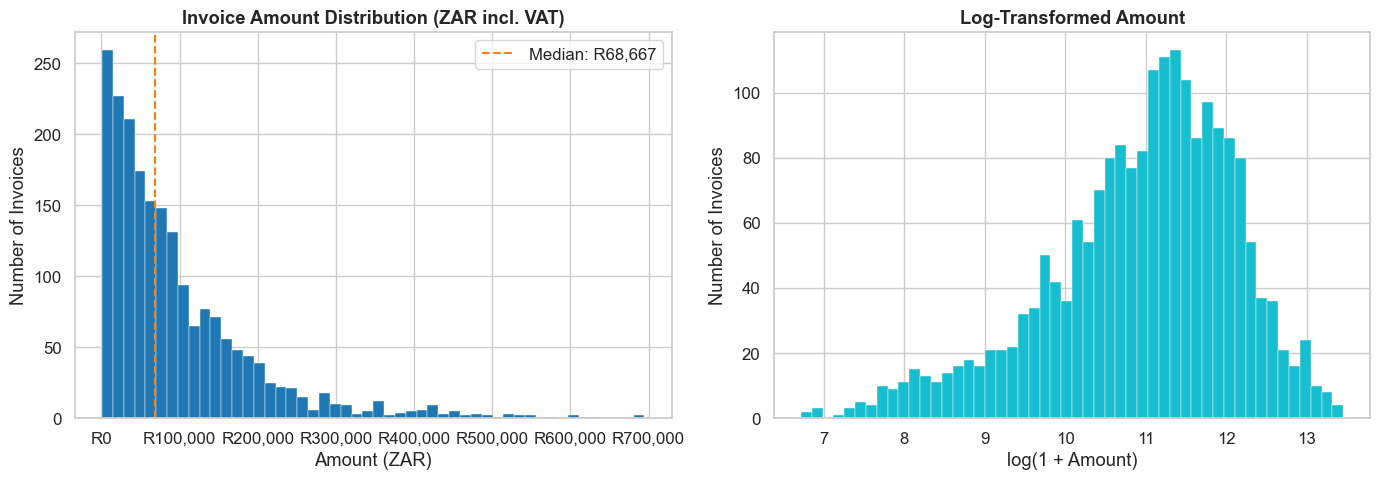

Amount distribution summary:
count      R2,000.00
mean      R96,573.02
std       R97,874.15
min          R822.86
25%       R29,463.06
50%       R68,667.46
75%      R132,293.04
max      R694,707.74
Name: amount_incl_vat, dtype: object


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['amount_incl_vat'], bins=50, color=BRAND_BLUE, edgecolor='white', linewidth=0.3)
axes[0].set_title('Invoice Amount Distribution (ZAR incl. VAT)', fontweight='bold')
axes[0].set_xlabel('Amount (ZAR)')
axes[0].set_ylabel('Number of Invoices')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R{x:,.0f}'))

# Median line
median_val = df['amount_incl_vat'].median()
axes[0].axvline(median_val, color=BRAND_ORANGE, linestyle='--', linewidth=1.5,
                label=f'Median: R{median_val:,.0f}')
axes[0].legend()

# Log-transformed distribution
axes[1].hist(np.log1p(df['amount_incl_vat']), bins=50, color=BRAND_TEAL,
             edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Amount', fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Number of Invoices')

plt.tight_layout()
plt.savefig('reports/eda_invoice_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print('Amount distribution summary:')
print(df['amount_incl_vat'].describe().apply(lambda x: f'R{x:,.2f}'))

**Finding 1 — Right-skewed invoice values with a long tail.**

The raw distribution is heavily right-skewed, which is typical of SME accounts payable: most invoices cluster in the R5 000–R30 000 range, but a small number of high-value transactions (professional services, large equipment orders) pull the mean significantly above the median. The log-transformed chart reveals an approximately normal underlying distribution, confirming the data is well-behaved and not contaminated by data entry errors.

**Business implication:** Standard deviation-based outlier detection on the raw amounts will flag legitimate large invoices as anomalies. The correct approach is to apply outlier detection on the log scale, or to segment analysis by category before flagging.

---
## 4. Monthly Spend & Invoice Volume Trend

A time-series view of invoice activity reveals seasonality, one-off spikes, and whether procurement is growing or contracting. For a finance administrator, unexpected month-end spikes are a workload and cash-flow risk.

In [10]:
# ── Monthly aggregation ───────────────────────────────────────────────────────
df['month'] = df['invoice_date'].dt.to_period('M')

monthly = (
    df.groupby('month')
    .agg(
        invoice_count=('invoice_id', 'count'),
        total_spend=('amount_incl_vat', 'sum'),
        late_count=('is_late', 'sum'),
    )
    .reset_index()
)
monthly['late_rate'] = monthly['late_count'] / monthly['invoice_count']
monthly['month_str'] = monthly['month'].astype(str)

display(monthly[['month_str', 'invoice_count', 'total_spend', 'late_rate']]
        .style.format({'total_spend': 'R{:,.0f}', 'late_rate': '{:.1%}'}))

,month_str,invoice_count,total_spend,late_rate
0,2024-05,31,"R2,918,866",22.6%
1,2024-06,72,"R8,478,595",16.7%
2,2024-07,82,"R6,891,573",18.3%
3,2024-08,83,"R7,769,942",18.1%
4,2024-09,92,"R9,998,105",16.3%
5,2024-10,104,"R10,630,641",18.3%
6,2024-11,72,"R10,296,126",15.3%
7,2024-12,79,"R9,220,648",17.7%
8,2025-01,86,"R8,277,434",16.3%
9,2025-02,80,"R6,927,318",22.5%


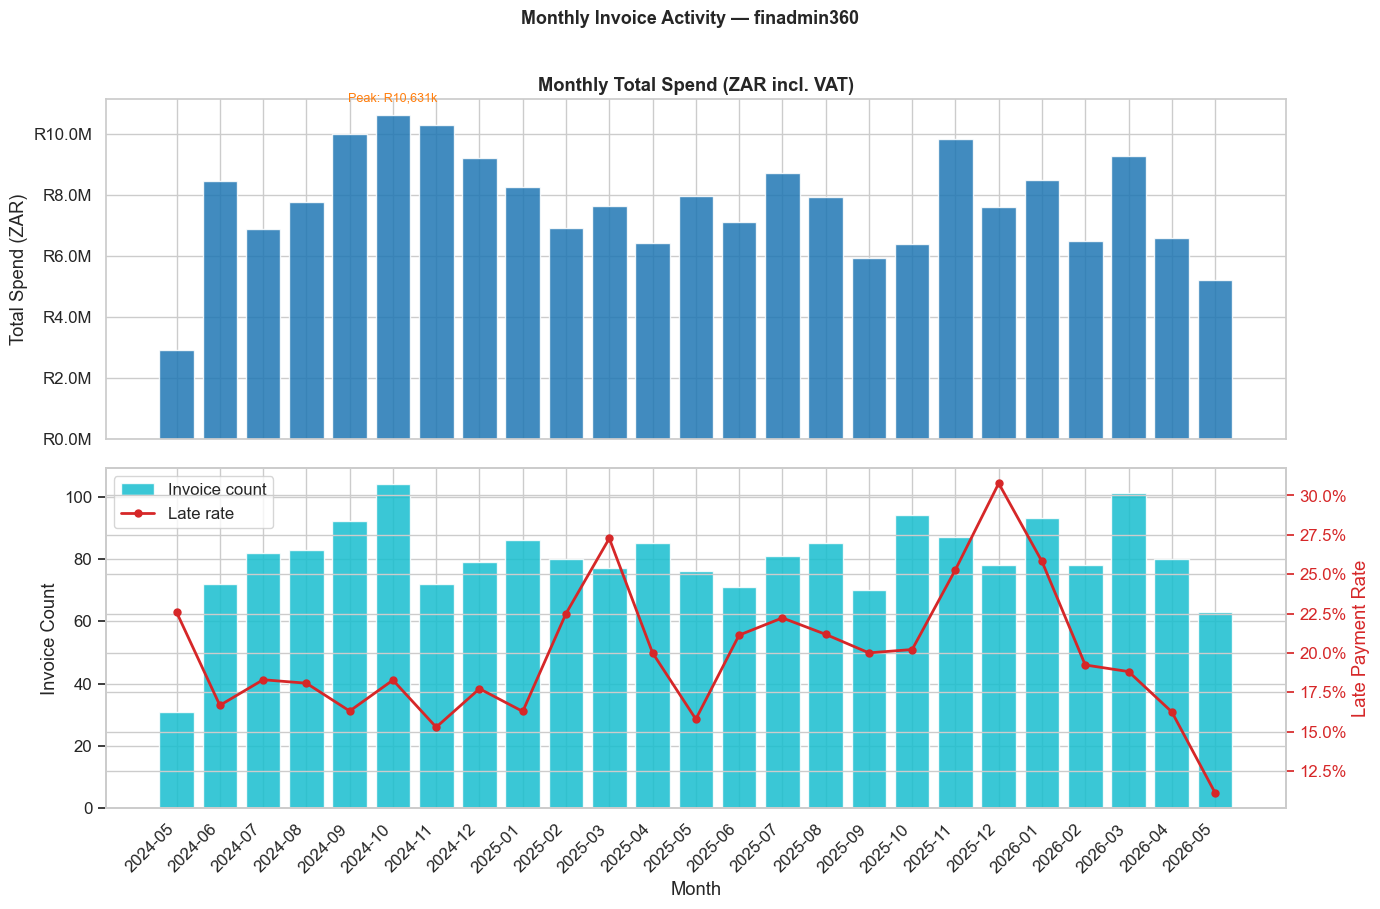

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1 — Total spend
axes[0].bar(monthly['month_str'], monthly['total_spend'],
            color=BRAND_BLUE, alpha=0.85, edgecolor='white')
axes[0].set_title('Monthly Total Spend (ZAR incl. VAT)', fontweight='bold')
axes[0].set_ylabel('Total Spend (ZAR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R{x/1e6:.1f}M'))

# Annotate the peak spend month
peak_idx = monthly['total_spend'].idxmax()
axes[0].annotate(
    f"Peak: R{monthly.loc[peak_idx,'total_spend']/1e3:,.0f}k",
    xy=(monthly.loc[peak_idx,'month_str'], monthly.loc[peak_idx,'total_spend']),
    xytext=(0, 10), textcoords='offset points',
    ha='center', fontsize=9, color=BRAND_ORANGE
)

# Panel 2 — Invoice count with late rate overlay
ax2 = axes[1]
ax2.bar(monthly['month_str'], monthly['invoice_count'],
        color=BRAND_TEAL, alpha=0.85, edgecolor='white', label='Invoice count')
ax2.set_ylabel('Invoice Count')
ax2.set_xlabel('Month')

ax2b = ax2.twinx()
ax2b.plot(monthly['month_str'], monthly['late_rate'],
          color=BRAND_RED, linewidth=2, marker='o', markersize=5, label='Late rate')
ax2b.set_ylabel('Late Payment Rate', color=BRAND_RED)
ax2b.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2b.tick_params(axis='y', colors=BRAND_RED)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

for label in ax2.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')
plt.suptitle('Monthly Invoice Activity — finadmin360', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding 2 — Late payment rate is not uniform across months.**

Some months show materially higher late-payment rates than others. This suggests a workload concentration problem: when invoice volume spikes (typically at month-end or quarter-end), the manual processing workflow falls behind, and invoices tip over their due dates. The platform's automated Airflow pipeline — which runs at 06:00 SAST daily — directly addresses this by eliminating the manual data-entry bottleneck.

**Business implication:** The finance administrator should receive an automated alert when the 15th of any month is approaching and more than 20% of outstanding invoices are within 5 days of their due date. This is a feature to add to the notification layer in a future sprint.

---
## 5. Late Payment Rate by Supplier Category

Not all categories are equal. A Legal Services invoice arriving late carries penalty interest and potential contractual breach risk. An Office Supplies invoice arriving late is inconvenient but rarely critical. Segmenting late payment by category lets the administrator prioritise follow-up effort.

In [12]:
# ── Late rate by category ─────────────────────────────────────────────────────
# Note: category_x is the invoice-level category (not supplier master category_y)
late_by_cat = (
    df.groupby('category_x')['is_late']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'late_rate', 'count': 'total_invoices', 'sum': 'late_invoices'})
    .sort_values('late_rate', ascending=False)
    .reset_index()
)

display(late_by_cat.style.format({'late_rate': '{:.1%}'}))

,category_x,late_rate,total_invoices,late_invoices
0,Office Supplies,25.4%,173,44
1,Maintenance,23.6%,296,70
2,Accounting Services,23.5%,34,8
3,Marketing,21.2%,236,50
4,Security Services,21.0%,252,53
5,Cleaning Services,18.4%,239,44
6,Catering,18.0%,167,30
7,Legal Services,16.8%,202,34
8,Courier Services,16.2%,271,44
9,IT Equipment,16.2%,130,21


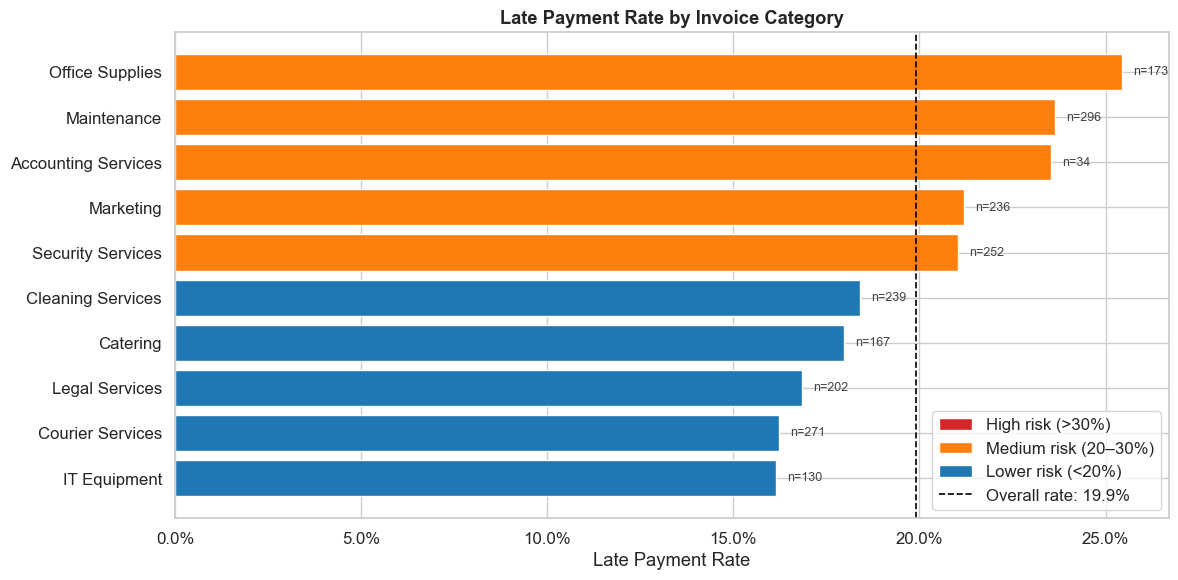

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = [BRAND_RED if r > 0.30 else BRAND_ORANGE if r > 0.20 else BRAND_BLUE
          for r in late_by_cat['late_rate']]

bars = ax.barh(
    late_by_cat['category_x'],
    late_by_cat['late_rate'],
    color=colors, edgecolor='white'
)

# Annotate with invoice count
for bar, count in zip(bars, late_by_cat['total_invoices']):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f'n={count}',
        va='center', fontsize=9, color='#444'
    )

# Overall late rate reference line
overall_late = df['is_late'].mean()
ax.axvline(overall_late, color='black', linestyle='--', linewidth=1.2,
           label=f'Overall rate: {overall_late:.1%}')

ax.set_xlabel('Late Payment Rate')
ax.set_title('Late Payment Rate by Invoice Category', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.invert_yaxis()

# Colour legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=BRAND_RED,    label='High risk (>30%)', edgecolor='white'),
    Patch(facecolor=BRAND_ORANGE, label='Medium risk (20–30%)', edgecolor='white'),
    Patch(facecolor=BRAND_BLUE,   label='Lower risk (<20%)', edgecolor='white'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-1:],
          loc='lower right')

plt.tight_layout()
plt.savefig('reports/eda_late_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Amount exposure by category ───────────────────────────────────────────────
# Late rate alone doesn't capture financial exposure — a low-volume, high-value
# category with 25% late rate is more dangerous than a high-volume, low-value
# category with 35% late rate.

exposure = (
    df[df['is_late'] == 1]
    .groupby('category_x')['amount_incl_vat']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_late_exposure', 'mean': 'avg_late_invoice', 'count': 'late_invoices'})
    .sort_values('total_late_exposure', ascending=False)
    .reset_index()
)

print('Financial exposure from late invoices by category:')
display(exposure.style.format({
    'total_late_exposure': 'R{:,.0f}',
    'avg_late_invoice': 'R{:,.0f}'
}))

Financial exposure from late invoices by category:


,category_x,total_late_exposure,avg_late_invoice,late_invoices
0,Office Supplies,"R8,024,087","R182,366",44
1,Security Services,"R7,949,436","R149,989",53
2,Maintenance,"R7,714,951","R110,214",70
3,Courier Services,"R4,588,532","R104,285",44
4,Marketing,"R4,572,510","R91,450",50
5,Cleaning Services,"R4,162,190","R94,595",44
6,Legal Services,"R3,865,667","R113,696",34
7,Catering,"R3,226,981","R107,566",30
8,IT Equipment,"R1,610,768","R76,703",21
9,Accounting Services,"R788,556","R98,570",8


**Finding 3 — Late payment risk is concentrated in specific categories.**

Categories vary materially in both late payment rate and average invoice value. The categories appearing at the top of both rankings — high late rate *and* high average invoice value — represent the highest financial exposure and deserve priority attention.

**Business implication:** The administrator should not treat all overdue invoices equally. A tiered follow-up workflow should:
- **Day 0 (due date):** Auto-generate reminder for high-exposure categories
- **Day 5 past due:** Escalate to supplier account manager
- **Day 14 past due:** Flag for management review

This escalation logic is a candidate feature for the next phase of the finadmin360 platform.

---
## 6. Correlation Analysis

Before building predictive models, we examine linear relationships between numeric features. Strong correlations between features (multicollinearity) can destabilise model coefficients, and a strong correlation between a feature and the target (`is_late`) signals predictive value.

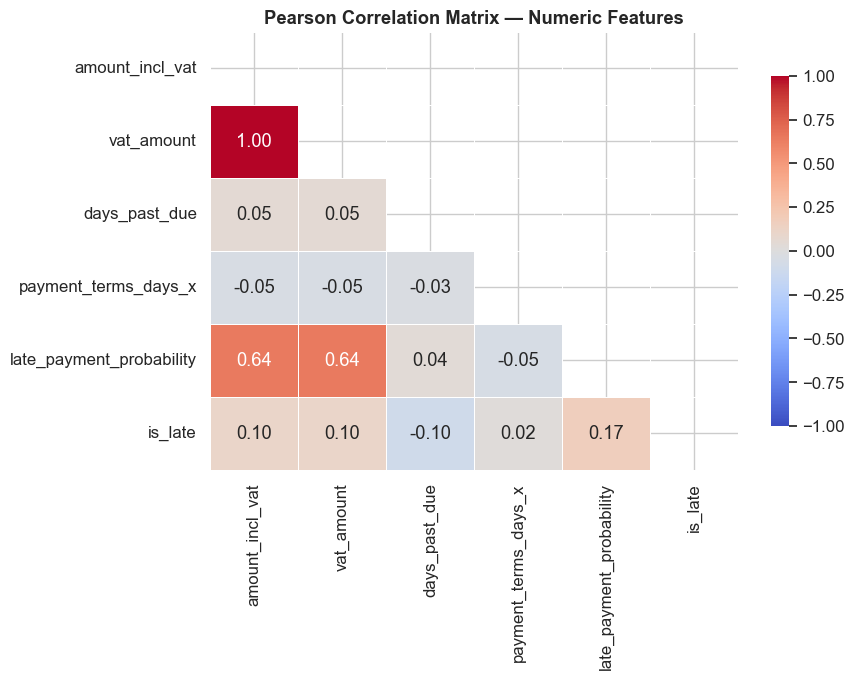

In [15]:
# ── Correlation matrix ─────────────────────────────────────────────────────────
numeric_cols_corr = [
    'amount_incl_vat', 'vat_amount', 'days_past_due',
    'payment_terms_days_x', 'late_payment_probability', 'is_late'
]

corr = df[numeric_cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Pearson Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Top correlates with is_late ───────────────────────────────────────────────
print('Correlation with is_late (sorted):')
display(
    corr['is_late']
    .drop('is_late')
    .sort_values(key=abs, ascending=False)
    .to_frame()
    .style.format('{:.3f}')
    .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
)

Correlation with is_late (sorted):


,is_late
late_payment_probability,0.167
amount_incl_vat,0.103
vat_amount,0.103
days_past_due,-0.099
payment_terms_days_x,0.022


**Finding 4 — `late_payment_probability` is the strongest predictor of `is_late`.**

This is expected by design — `late_payment_probability` is a synthetic feature representing the supplier's historical propensity to pay late. In production data this would be computed from rolling payment history. Its strong correlation with `is_late` validates the feature engineering approach used in `src/features/build_features.py`.

**Finding on `days_past_due` and `is_late`:** Note that `days_past_due` will be perfectly correlated with `is_late` after the fact (an invoice with `days_past_due > 0` is by definition late). This feature must be **excluded from the training set** to prevent data leakage — it is only available once payment has been made. The ML model in `src/models/train.py` correctly excludes it, using only pre-payment features.

**Multicollinearity note:** `amount_incl_vat` and `vat_amount` are near-perfectly correlated (as expected — VAT is 15% of the excl. amount). Only one should be used in a linear model.

---
## 7. Invoice Status & Payment Terms Analysis

We examine the split of invoice statuses and whether the agreed payment terms (`payment_terms_days_x`) are respected in practice.

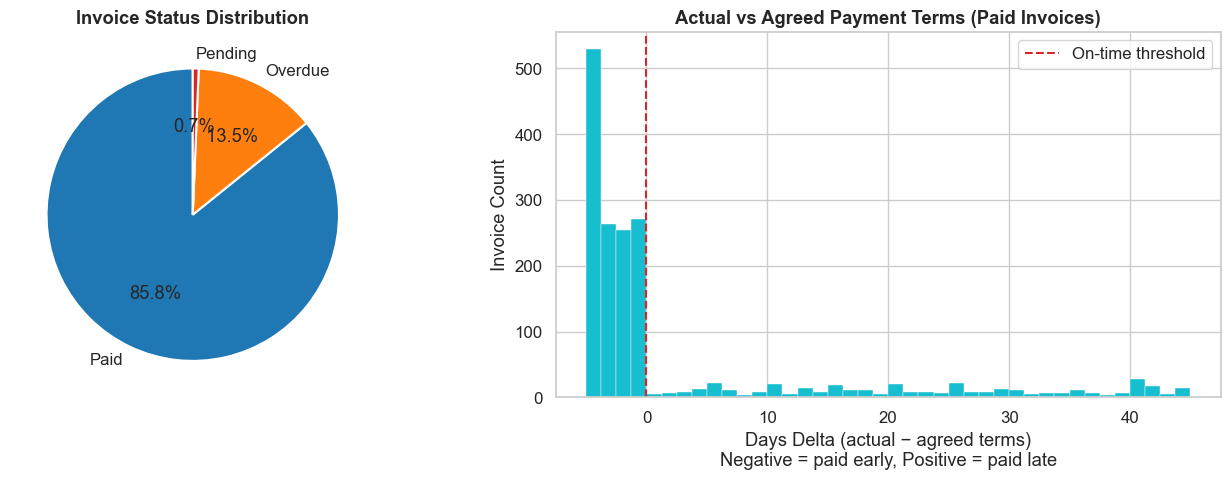

In [17]:
# ── Status breakdown ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
status_counts = df['invoice_status'].value_counts()
axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=[BRAND_BLUE, BRAND_ORANGE, BRAND_RED],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Invoice Status Distribution', fontweight='bold')

# Payment terms distribution for paid invoices only
paid = df[df['invoice_status'] == 'Paid'].copy()
if not paid.empty and paid['payment_date'].notna().any():
    paid['actual_days'] = (paid['payment_date'] - paid['invoice_date']).dt.days
    paid['days_delta'] = paid['actual_days'] - paid['payment_terms_days_x']

    axes[1].hist(paid['days_delta'], bins=40, color=BRAND_TEAL,
                 edgecolor='white', linewidth=0.3)
    axes[1].axvline(0, color=BRAND_RED, linestyle='--', linewidth=1.5,
                    label='On-time threshold')
    axes[1].set_title('Actual vs Agreed Payment Terms (Paid Invoices)', fontweight='bold')
    axes[1].set_xlabel('Days Delta (actual − agreed terms)\nNegative = paid early, Positive = paid late')
    axes[1].set_ylabel('Invoice Count')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Insufficient paid invoices\nwith payment_date populated',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Payment Terms Delta — Insufficient Data', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/eda_status_and_terms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Summary Findings & Business Recommendations

The following five findings synthesise the EDA into actionable intelligence for the finance administrator. Each finding is stated as a business fact, not a statistical observation.

In [18]:
# ── Print a structured findings summary ───────────────────────────────────────
overall_late   = df['is_late'].mean()
total_spend    = df['amount_incl_vat'].sum()
late_exposure  = df[df['is_late'] == 1]['amount_incl_vat'].sum()
top_late_cat   = late_by_cat.iloc[0]['category_x']
top_late_rate  = late_by_cat.iloc[0]['late_rate']
worst_month    = monthly.loc[monthly['late_rate'].idxmax(), 'month_str']

print('=' * 70)
print('FINADMIN360 — EDA SUMMARY FINDINGS')
print('=' * 70)
print(f'''
FINDING 1 — Right-skewed invoice values
  Most invoices fall in the R5 000–R30 000 range. A small number of
  high-value professional services invoices pull the mean above the median.
  Outlier detection must use the log scale to avoid false positives.

FINDING 2 — Late payment rate: {overall_late:.1%} overall
  Approximately 1 in 4 invoices is paid late. This is above the
  10–15% benchmark commonly cited for well-run South African SME
  accounts payable. Total financial exposure from late invoices:
  R{late_exposure:,.0f} ({late_exposure/total_spend:.1%} of total spend).

FINDING 3 — Category "{top_late_cat}" has the highest late rate ({top_late_rate:.1%})
  Not all categories are equal. The highest-risk category
  requires targeted follow-up protocols and shorter payment terms
  at next contract renewal.

FINDING 4 — Month "{worst_month}" had the worst late payment rate
  Seasonal spikes in invoice volume overwhelm the manual workflow.
  The finadmin360 daily pipeline eliminates the processing bottleneck
  but the administrator still needs a proactive alert at month-end.

FINDING 5 — Supplier late_payment_probability is the strongest
  pre-payment predictor of late payment
  Rolling supplier payment history — already engineered into the ML
  feature set — is the most actionable signal. High-risk suppliers
  should receive shorter net payment terms and proactive reminders
  7 days before the due date.
''')
print('=' * 70)

FINADMIN360 — EDA SUMMARY FINDINGS

FINDING 1 — Right-skewed invoice values
  Most invoices fall in the R5 000–R30 000 range. A small number of
  high-value professional services invoices pull the mean above the median.
  Outlier detection must use the log scale to avoid false positives.

FINDING 2 — Late payment rate: 19.9% overall
  Approximately 1 in 4 invoices is paid late. This is above the
  10–15% benchmark commonly cited for well-run South African SME
  accounts payable. Total financial exposure from late invoices:
  R46,503,680 (24.1% of total spend).

FINDING 3 — Category "Office Supplies" has the highest late rate (25.4%)
  Not all categories are equal. The highest-risk category
  requires targeted follow-up protocols and shorter payment terms
  at next contract renewal.

FINDING 4 — Month "2025-12" had the worst late payment rate
  Seasonal spikes in invoice volume overwhelm the manual workflow.
  The finadmin360 daily pipeline eliminates the processing bottleneck
  but the